# GOES Model Inference

Fine-tuned CNN for classification of cloud mesoscale structure in GOES/ABI imagery. The original CNN is
from Wu et al., 2025 (https://doi.org/10.5194/essd-17-3243-2025); the original
CNN can be accessed at https://zenodo.org/records/15776241.

Training Data Available on EarthCODE.

Input GOES data are available from https://www.goes.noaa.gov/.

## Model

- Task: classify GOES image chips into mesoscale cloud morphology classes
- Architecture: `timm` `resnet50d`
- Input shape: `(batch, 4, 128, 128)`
- Output classes: 6
- Fine-tuned date in source metadata: `2026-01-26 18:16:13`
- Best validation accuracy: `80.2083%`

## Inputs

| Channel | Name | Description |
|---:|---|---|
| 0 | `BT15_minus_BT14` | Normalized GOES BT15 - BT14 brightness-temperature difference. |
| 1 | `BT14_minus_BT11` | Normalized GOES BT14 - BT11 brightness-temperature difference. |
| 2 | `BT14` | Normalized GOES ABI channel-14 brightness temperature. |
| 3 | `COD` | Normalized GOES cloud optical depth. |

## Outputs

The model emits six logits. Apply softmax to get class probabilities.

| Class ID | Class Name |
|---:|---|
| 0 | Solid stratus |
| 1 | Closed MCC |
| 2 | Open MCC |
| 3 | Disorganized MCC |
| 4 | Clustered Cu |
| 5 | Suppressed Cu |



To run the below example the following libraries are needed:
`conda create -n earthcode-inference -c conda-forge python=3.13 torch==2.11.0 timm==1.0.27 safetensors==0.7.0 onnxruntime==1.24.2 numpy==2.2.6 gcsfs==2025.5.1 fsspec==2025.5.1 matplotlib pandas xarray pyproj scipy`

Then use with

`conda activate earthcode-inference`

In [4]:
from pathlib import Path
import os

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
from torch import nn
import xarray as xr
import onnxruntime as ort
from pyproj import Transformer
from safetensors.torch import load_file
from scipy.ndimage import zoom

notebook_dir = Path('./')

## Helper Functions

In [5]:
# Copied from mesoscale_structure-main/judge_for_goes/functions_for_goes.py
def convert_radiance_to_brightness_temp(ds):
    fk1 = ds["planck_fk1"]
    fk2 = ds["planck_fk2"]
    bc1 = ds["planck_bc1"]
    bc2 = ds["planck_bc2"]

    bt = (fk2 / (np.log((fk1 / ds.Rad) + 1)) - bc1) / bc2
    ds["BT"] = (ds.Rad.dims, bt.values)
    ds["BT"].attrs = {
        "long_name": "Brightness Temperature",
        "units": "K",
        "standard_name": "brightness_temperature",
    }
    return ds


# Copied from mesoscale_structure-main/judge_for_goes/functions_for_goes.py
def add_latlon_to_goes(ds):
    proj_info = ds["goes_imager_projection"]
    sat_height = proj_info.attrs.get("perspective_point_height", 35786023.0)
    sat_lon = proj_info.attrs.get("longitude_of_projection_origin", -137.0)
    sat_sweep = proj_info.attrs.get("sweep_angle_axis", "x")

    x_m = ds.x.values * sat_height
    y_m = ds.y.values * sat_height

    proj_string = f"+proj=geos +h={sat_height} +lon_0={sat_lon} +sweep={sat_sweep} +ellps=GRS80 +units=m +no_defs"
    transformer = Transformer.from_crs(proj_string, "EPSG:4326", always_xy=True)

    X_m, Y_m = np.meshgrid(x_m, y_m)
    lon, lat = transformer.transform(X_m, Y_m)

    return ds.assign_coords({
        "longitude": (("y", "x"), lon),
        "latitude": (("y", "x"), lat),
    })

def crop_goes_to_latlon_box(ds, lat_bounds, lon_bounds):
    """
    Crop GOES data to a lat/lon bounding box
    
    Parameters:
    - ds: xarray Dataset with GOES data
    - lat_bounds: tuple (lat_min, lat_max)
    - lon_bounds: tuple (lon_min, lon_max)
    """
    
    # Add lat/lon coordinates if not present
    if 'latitude' not in ds.coords or 'longitude' not in ds.coords:
        ds = add_latlon_to_goes(ds)
    
    # Get bounds
    lat_min, lat_max = lat_bounds
    lon_min, lon_max = lon_bounds
    
    # Create mask for the region
    lat_mask = (ds.latitude >= lat_min) & (ds.latitude <= lat_max)
    lon_mask = (ds.longitude >= lon_min) & (ds.longitude <= lon_max)
    combined_mask = lat_mask & lon_mask
    
    # Find indices where mask is True
    y_indices, x_indices = np.where(combined_mask)
    
    if len(y_indices) == 0:
        print("No data found in specified region")
        return None
    
    # Get bounding box in array coordinates
    y_min, y_max = y_indices.min(), y_indices.max()
    x_min, x_max = x_indices.min(), x_indices.max()
    
    # Add some padding if desired
    padding = 10  # pixels
    y_min = max(0, y_min - padding)
    y_max = min(ds.dims['y'] - 1, y_max + padding)
    x_min = max(0, x_min - padding)
    x_max = min(ds.dims['x'] - 1, x_max + padding)
    
    # Crop the dataset
    ds_cropped = ds.isel(y=slice(y_min, y_max+1), x=slice(x_min, x_max+1))
    
    print(f"Original shape: {ds.dims}")
    print(f"Cropped shape: {ds_cropped.dims}")
    print(f"Lat range: {ds_cropped.latitude.min().values:.2f} to {ds_cropped.latitude.max().values:.2f}")
    print(f"Lon range: {ds_cropped.longitude.min().values:.2f} to {ds_cropped.longitude.max().values:.2f}")
    
    return ds_cropped


# Copied from mesoscale_structure-main/judge_for_goes/judge_goes19.py
def preprocess_data(BT_11, BT_14, BT_15, COD, window_size=128, xy_indices=None):
    scale_factor = 2
    COD_interpolated = xr.DataArray(zoom(COD.values, scale_factor, order=1), dims=["y", "x"])

    latitudes = zoom(BT_11.latitude.values, scale_factor, order=1)
    longitudes = zoom(BT_11.longitude.values, scale_factor, order=1)
    BT_11 = xr.DataArray(zoom(BT_11.values, scale_factor, order=1), dims=["y", "x"])
    BT_14 = xr.DataArray(zoom(BT_14.values, scale_factor, order=1), dims=["y", "x"])
    BT_15 = xr.DataArray(zoom(BT_15.values, scale_factor, order=1), dims=["y", "x"])

    if xy_indices is None:
        y_indices = np.arange(64, BT_11.shape[0] - 64, 64)
        x_indices = np.arange(64, BT_11.shape[1] - 64, 64)
        y_grid, x_grid = np.meshgrid(y_indices, x_indices, indexing="ij")
        xy_indices = list(zip(x_grid.flatten(), y_grid.flatten()))

    all_weirgb = []
    all_scenes_params = {"y_idx": [], "x_idx": [], "lon_mid": [], "lat_mid": [], "ice_flag": [], "cloud_cover": [], "ot_gt_1": [], "ot_gt_5": []}

    for i, j in xy_indices:
        lat_mid = latitudes[j, i]
        lon_mid = longitudes[j, i]

        data11 = BT_11[j - window_size // 2 : j + window_size // 2, i - window_size // 2 : i + window_size // 2].values
        data22 = BT_14[j - window_size // 2 : j + window_size // 2, i - window_size // 2 : i + window_size // 2].values
        data33 = BT_15[j - window_size // 2 : j + window_size // 2, i - window_size // 2 : i + window_size // 2].values

        R = data33 - data22
        G = data22 - data11
        B = data22

        R = (R - np.min(R)) / (np.max(R) - np.min(R))
        G = (G - np.min(G)) / (np.max(G) - np.min(G))
        G = np.power(G, 1 / 2)
        B = (B - np.min(B)) / (np.max(B) - np.min(B))

        cot1 = COD_interpolated[j - window_size // 2 : j + window_size // 2, i - window_size // 2 : i + window_size // 2].values
        cot2 = cot1.copy() if np.min(cot1) == np.max(cot1) else (cot1 - np.min(cot1)) / (np.max(cot1) - np.min(cot1))

        weirgb = np.zeros((4, 128, 128))
        weirgb[0, :, :] = R
        weirgb[1, :, :] = G
        weirgb[2, :, :] = B
        weirgb[3, :, :] = cot2

        ice_flag = np.sum(data22 < 273) / (window_size * window_size)
        orig_i, orig_j = i // 2, j // 2
        original_window_size = window_size // 2
        cot_original = COD[orig_j - original_window_size // 2 : orig_j + original_window_size // 2, orig_i - original_window_size // 2 : orig_i + original_window_size // 2].values
        cloud_cover = np.sum(cot_original > 0) / (original_window_size * original_window_size)
        ot_gt_1 = np.sum(cot_original > 1) / (original_window_size * original_window_size)
        ot_gt_5 = np.sum(cot_original > 5) / (original_window_size * original_window_size)

        all_scenes_params["y_idx"].append(j)
        all_scenes_params["x_idx"].append(i)
        all_scenes_params["lon_mid"].append(lon_mid)
        all_scenes_params["lat_mid"].append(lat_mid)
        all_scenes_params["ice_flag"].append(ice_flag)
        all_scenes_params["cloud_cover"].append(cloud_cover)
        all_scenes_params["ot_gt_1"].append(ot_gt_1)
        all_scenes_params["ot_gt_5"].append(ot_gt_5)
        all_weirgb.append(weirgb)

    return np.array(all_weirgb), all_scenes_params

## Download Inputs

In [6]:
import gcsfs


def download_goes_simple(datetime, level='L2', satellite_id='19', product='COD2KMF', 
                          save_dir=os.path.join(notebook_dir, 'mesoscale_structure-main', 'goes_valid_sample')):
    """
    Simple approach: Download full files first, then process
    """
    os.makedirs(save_dir, exist_ok=True)
    
    fs = gcsfs.GCSFileSystem()
    bucket = f"gcp-public-data-goes-{satellite_id}"
    
    dt = pd.Timestamp(datetime)
    year = dt.year
    day_of_year = dt.timetuple().tm_yday
    hour = dt.hour
    
    path = f"{bucket}/ABI-{level}-{product}/{year}/{day_of_year:03d}/{hour:02d}/"
    
    try:
        files = fs.ls(path)
        
        if files:
            # Download first file of the hour
            remote_file = files[0]
            local_file = os.path.join(save_dir, 
                                    f"{remote_file.split('/')[-1]}")
            
            print(f"Downloading: {remote_file}")
            fs.get(remote_file, local_file)
            print(f"Saved: {local_file}")
            
    except Exception as e:
        print(f"Error downloading {dt}: {e}")

def download_goes_ir_channels(datetime, satellite_id='19', channels=['11', '14', '15'],
                                rad_type='RadF', save_dir=os.path.join(notebook_dir, 'mesoscale_structure-main', 'goes_valid_sample')):
    """
    Download specific GOES-19 IR channels (corrected for actual filename format)
    
    Parameters:
    - channels: List of channel numbers as strings ['11', '14', '15']
    - rad_type: 'RadC' (CONUS), 'RadF' (Full Disk), or 'RadM' (Mesoscale)
    """
    os.makedirs(save_dir, exist_ok=True)
    
    fs = gcsfs.GCSFileSystem()
    bucket = f"gcp-public-data-goes-{satellite_id}"
    
    dt = pd.Timestamp(datetime)
    year = dt.year
    day_of_year = dt.timetuple().tm_yday
    hour = dt.hour
    
    print(f"\n=== {dt.strftime('%Y-%m-%d %H:%M')} ===")
    
    # List all files for this hour to find the channels
    path = f"{bucket}/ABI-L1b-{rad_type}/{year}/{day_of_year:03d}/{hour:02d}/"
    
    try:
        files = fs.ls(path)
        
        # Show available channels first
        available_channels = set()
        for f in files:
            filename = f.split('/')[-1]
            if '-M6C' in filename:
                channel = filename.split('-M6C')[1][:2]
                available_channels.add(channel)
        
        print(f"  Available channels: {sorted(available_channels)}")
        
        # Filter files for each requested channel
        for channel in channels:
            # Look for pattern like -M6C07_ in filename
            channel_files = [f for f in files if f'-M6C{channel}_' in f]
            
            if channel_files:
                # Download first file for this channel
                remote_file = channel_files[0]
                local_file = os.path.join(save_dir, 
                                        f"{remote_file.split('/')[-1]}")
                
                print(f"  Channel {channel}: {remote_file.split('/')[-1]}")
                fs.get(remote_file, local_file)
                print(f"  Saved: {os.path.basename(local_file)}")
            else:
                print(f"  Channel {channel}: No files found")
                
    except Exception as e:
        print(f"  Error: {e}")


In [7]:
download_goes_simple(
    datetime=pd.Timestamp(2025, 8, 1, 18, 0), 
    level='L2', 
    satellite_id='19', 
    product='COD2KMF', 
    save_dir=os.path.join(notebook_dir, 'mesoscale_structure-main', 'goes_valid_sample'))

download_goes_ir_channels(
        datetime=pd.Timestamp(2025, 8, 1, 18, 0),
        satellite_id='19',
        channels=['11', '14', '15'],  # IR window channels
        rad_type='RadF',  # Full Disk coverage
        save_dir=os.path.join(notebook_dir, 'mesoscale_structure-main', 'goes_valid_sample')
    )

Downloading: gcp-public-data-goes-19/ABI-L2-COD2KMF/2025/213/18/OR_ABI-L2-COD2KMF-M6_G19_s20252131800212_e20252131809520_c20252131814175.nc
Saved: ./mesoscale_structure-main/goes_valid_sample/OR_ABI-L2-COD2KMF-M6_G19_s20252131800212_e20252131809520_c20252131814175.nc

=== 2025-08-01 18:00 ===
  Available channels: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16']
  Channel 11: OR_ABI-L1b-RadF-M6C11_G19_s20252131800212_e20252131809520_c20252131809574.nc
  Saved: OR_ABI-L1b-RadF-M6C11_G19_s20252131800212_e20252131809520_c20252131809574.nc
  Channel 14: OR_ABI-L1b-RadF-M6C14_G19_s20252131800212_e20252131809520_c20252131809583.nc
  Saved: OR_ABI-L1b-RadF-M6C14_G19_s20252131800212_e20252131809520_c20252131809583.nc
  Channel 15: OR_ABI-L1b-RadF-M6C15_G19_s20252131800212_e20252131809526_c20252131809593.nc
  Saved: OR_ABI-L1b-RadF-M6C15_G19_s20252131800212_e20252131809526_c20252131809593.nc


## Paths

In [ ]:
# Download safetensors and onnx to SAFETENSORS_PATH and ONNX_PATH from links
!curl -L "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/earthcare-marine-stratocumulus-transitions/goes_cloud_regime_classifier/v0.1.0/model.safetensors" -o model.safetensors
!curl -L "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/earthcare-marine-stratocumulus-transitions/goes_cloud_regime_classifier/v0.1.0/model.onnx" -o model.onnx

In [8]:
GOES_C11 = Path("mesoscale_structure-main", "goes_valid_sample", "OR_ABI-L1b-RadF-M6C11_G19_s20252131800212_e20252131809520_c20252131809574.nc")
GOES_C14 = Path("mesoscale_structure-main", "goes_valid_sample", "OR_ABI-L1b-RadF-M6C14_G19_s20252131800212_e20252131809520_c20252131809583.nc")
GOES_C15 = Path("mesoscale_structure-main", "goes_valid_sample", "OR_ABI-L1b-RadF-M6C15_G19_s20252131800212_e20252131809526_c20252131809593.nc")
GOES_COD = Path("mesoscale_structure-main", "goes_valid_sample", "OR_ABI-L2-COD2KMF-M6_G19_s20252131800212_e20252131809520_c20252131814175.nc")

#PACKAGE_DIR = Path("EarthCODE_FAIR/goes_cloud_regime_classifier/v0.1.0") #--- IGNORE ---
PACKAGE_DIR = Path(notebook_dir) #Path("./v0.1.0").parent
SAFETENSORS_PATH = PACKAGE_DIR / "model.safetensors"
ONNX_PATH = PACKAGE_DIR / "model.onnx"

CLASS_NAMES = ["Solid stratus", "Closed MCC", "Open MCC", "Disorganized MCC", "Clustered Cu", "Suppressed Cu"]
MODEL_CHANNELS = ["BT15 - BT14", "BT14 - BT11", "BT14", "COD"]

## Open GOES Inputs

In [ ]:
raw_half_window = 32

# the CNN is created for stratocumulus clouds. We demonstrate it for the Southeast Pacific stratocumulus deck
lat_bounds = (-25, -2.5)
lon_bounds = (-95, -75)

with xr.open_dataset(PACKAGE_DIR / GOES_COD) as ds:
    ds_SEP = crop_goes_to_latlon_box(ds, lat_bounds, lon_bounds)

    coarse = ds_SEP["COD"].fillna(0).isel(
        y=slice(raw_half_window, -raw_half_window, 64),
        x=slice(raw_half_window, -raw_half_window, 64),
    ).load()
    coarse_y, coarse_x = np.unravel_index(np.argmax(coarse.values), coarse.shape)
    center_y = int(raw_half_window + coarse_y * 64)
    center_x = int(raw_half_window + coarse_x * 64)

y_window = slice(center_y - raw_half_window, center_y + raw_half_window)
x_window = slice(center_x - raw_half_window, center_x + raw_half_window)

def open_bt(path):
    # convert_radiance_to_brightness_temp from functions_for_goes.py
    with xr.open_dataset(path) as ds:
        ds_SEP = crop_goes_to_latlon_box(ds, lat_bounds, lon_bounds)
        ds_SEP = ds_SEP.isel(y=y_window, x=x_window)
        ds_SEP = convert_radiance_to_brightness_temp(ds_SEP)
        return ds_SEP["BT"].load()


BT_11 = open_bt(PACKAGE_DIR / GOES_C11)
BT_14 = open_bt(PACKAGE_DIR / GOES_C14)
BT_15 = open_bt(PACKAGE_DIR / GOES_C15)

with xr.open_dataset(PACKAGE_DIR / GOES_COD) as ds:
    ds_SEP = crop_goes_to_latlon_box(ds, lat_bounds, lon_bounds)
    COD = ds_SEP["COD"].isel(y=y_window, x=x_window).fillna(0).load()

center_y, center_x, BT_11.shape

## Preprocess

In [10]:
# preprocess_data from judge_goes19.py
all_weirgb, scenes_params = preprocess_data(
    BT_11,
    BT_14,
    BT_15,
    COD,
    window_size=128,
    xy_indices=[(64, 64)],
)

model_chip = all_weirgb[0].astype("float32")
pd.DataFrame(scenes_params)

,y_idx,x_idx,lon_mid,lat_mid,ice_flag,cloud_cover,ot_gt_1,ot_gt_5
0,64,64,-88.433746,-5.22443,0.0,1.0,1.0,0.956055


## Safetensors Inference

In [11]:
def build_goes_model():
    # model construction in judge_goes19.py::judge_GOES
    model = timm.create_model("resnet50d", pretrained=False)
    model.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(2048, 6)
    return model


model_torch = build_goes_model()
model_torch.load_state_dict(load_file(SAFETENSORS_PATH))
model_torch.eval()

input_tensor = torch.from_numpy(model_chip).unsqueeze(0).to(torch.float32)

with torch.no_grad():
    logits_torch = model_torch(input_tensor)
    probabilities_torch = torch.softmax(logits_torch, dim=1).numpy()[0]

result_safetensors = pd.DataFrame({
    "class_id": range(len(CLASS_NAMES)),
    "class_name": CLASS_NAMES,
    "probability_safetensors": probabilities_torch,
}).sort_values("probability_safetensors", ascending=False)

result_safetensors

,class_id,class_name,probability_safetensors
1,1,Closed MCC,9.966990e-01
3,3,Disorganized MCC,1.316166e-03
2,2,Open MCC,9.270489e-04
0,0,Solid stratus,8.725640e-04
4,4,Clustered Cu,1.851608e-04
5,5,Suppressed Cu,9.359333e-09


## ONNX Inference

In [12]:
def softmax_numpy(logits):
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


session = ort.InferenceSession(str(ONNX_PATH))
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

input_array = model_chip[None, ...].astype("float32")
logits_onnx = session.run([output_name], {input_name: input_array})[0]
probabilities_onnx = softmax_numpy(logits_onnx)[0]

result_onnx = pd.DataFrame({
    "class_id": range(len(CLASS_NAMES)),
    "class_name": CLASS_NAMES,
    "probability_onnx": probabilities_onnx,
}).sort_values("probability_onnx", ascending=False)

result_onnx

,class_id,class_name,probability_onnx
1,1,Closed MCC,9.966992e-01
3,3,Disorganized MCC,1.316177e-03
2,2,Open MCC,9.270587e-04
0,0,Solid stratus,8.725740e-04
4,4,Clustered Cu,1.851624e-04
5,5,Suppressed Cu,9.359459e-09


## Labelled Data

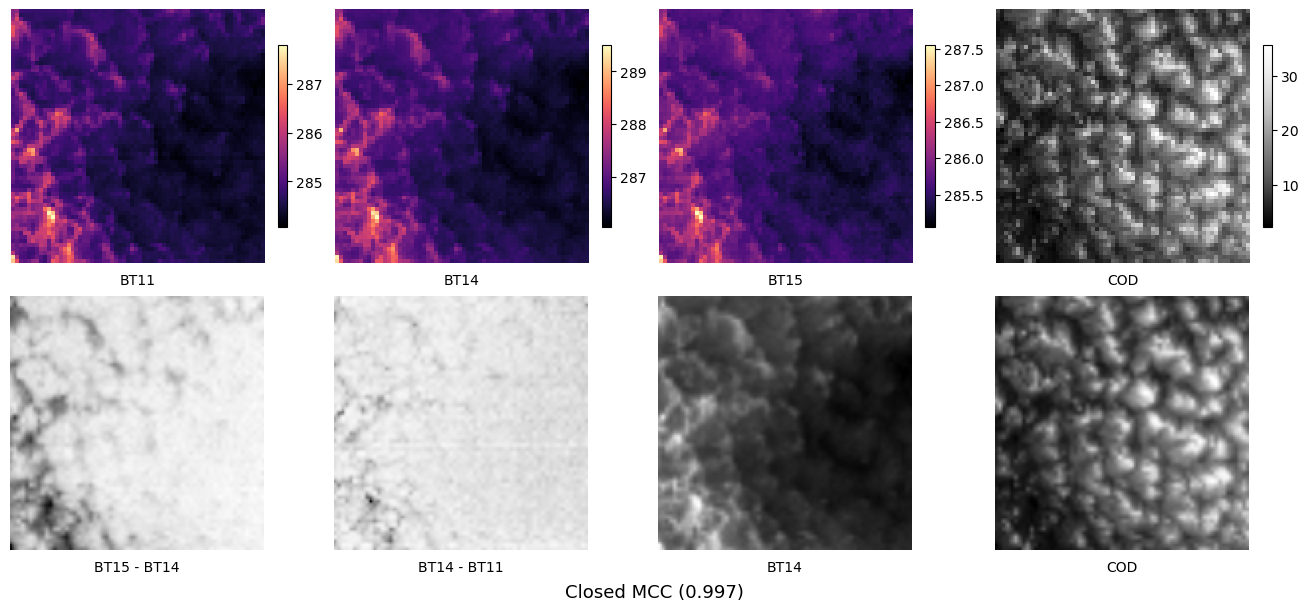

In [13]:
label = result_onnx.iloc[0]["class_name"]
probability = result_onnx.iloc[0]["probability_onnx"]

fig, axes = plt.subplots(2, 4, figsize=(13, 6), constrained_layout=True)

for ax, data, channel_label, cmap in zip(
    axes[0],
    [BT_11, BT_14, BT_15, COD],
    ["BT11", "BT14", "BT15", "COD"],
    ["magma", "magma", "magma", "Greys_r"],
):
    image = ax.imshow(data.values, cmap=cmap)
    ax.set_xlabel(channel_label, labelpad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    fig.colorbar(image, ax=ax, shrink=0.72)

for ax, data, channel_label in zip(axes[1], model_chip, MODEL_CHANNELS):
    ax.imshow(data, cmap="Greys_r")
    ax.set_xlabel(channel_label, labelpad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

fig.supxlabel(f"{label} ({probability:.3f})", fontsize=13)
plt.show()